In [75]:
##############
## INITIATE ##
##############

## Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch

## Import modules
from f_wsi_reader import slide_path_to_tiles_at_coordinates
from f_wsi_reader import get_tile_map
from f_wsi_reader import get_tile_map_fast
from f_wsi_reader import read_slide
from f_wsi_reader import get_dimensions
from f_wsi_reader import apply_all_filters
from f_wsi_reader import apply_all_transforms
from f_wsi_reader import reassemble_tiles
from f_wsi_reader import select_patches_on_grid
from f_wsi_reader import get_tissue_mask
from f_extract_objects import extract_object_pixels
from f_extract_objects import polish
from f_extract_objects import inlay_objects
from f_extract_objects import get_bounding_box_square
# from f_model import UNet as Model
from f_model_transformer import UNetTransformer as Model

#
###

In [117]:
###########
## PATHS ##
###########

## Paths
wsi_paths = ['/Volumes/Elements/BDI/datasets/ICGCC/images/svs/TB10.0230_V10_03.svs',
             '/Volumes/Elements/BDI/datasets/ICGCC/images/svs/TB10.1062_V6_01.svs',
             '/Volumes/Elements/BDI/datasets/ICGCC/images/svs/TB11.1039_V2_04.svs',
             '/Volumes/Elements/BDI/datasets/ICGCC/images/svs/TB13.0193_V8_13.svs',
             '/Volumes/Elements/BDI/datasets/TCGA/images/svs/TCGA-HC-7213-01A_1.svs',
             '/Volumes/Elements/BDI/datasets/TCGA/images/svs/TCGA-HC-7821-01A_1.svs',
             '/Volumes/Elements/BDI/datasets/TCGA/images/svs/TCGA-XJ-A83F-01A_1.svs',
             '/Volumes/Elements/BDI/datasets/TCGA/images/svs/TCGA-Y6-A8TL-01A_1.svs',
             '/Volumes/Elements/BDI/datasets/TCGA_FFPE/images/svs/TCGA-HC-7742-01Z-00-DX1.59cf7b97-16a4-4c83-b4e0-6ee292326500.svs',
             '/Volumes/Elements/BDI/datasets/TCGA_FFPE/images/svs/TCGA-HC-8257-01Z-00-DX1.f11b1c83-b2d6-4e96-af6f-672bcf6719f4.svs',
             '/Volumes/Elements/BDI/datasets/TCGA_FFPE/images/svs/TCGA-HC-A6HX-01Z-00-DX1.7122F7F6-971E-4608-A0EE-0190D5F74216.svs',
             '/Volumes/Elements/BDI/datasets/TCGA_FFPE/images/svs/TCGA-HC-A6HY-01Z-00-DX1.9753A5EC-6068-4502-ACBB-4C6F1EA77AF9.svs',
            ]

## Path to output
PT_OUTPUT_FOLDER = f'/Volumes/Elements/BDI/datasets/SEGG/images/external-validation' # Path where the gland images should be saved

#
###

In [118]:
##########################
## GET TILE COORDINATES ##
##########################

## Parameters
TILE_SIZE = 64 # Size of tiles for tissue extraction
FILTER_LOW = 10 # Low filter to remove black tiles
FILTER_HIGH = 240 # High filter to remove white tiles
FILTER_STD = 2 # Std filter to remove grey tiles
WSI_PATH = wsi_paths[6] # Path to WSI

## Open slide
slide = read_slide(WSI_PATH)
slide_size = get_dimensions(slide)

## Get tile_map
thumbnail, tile_map, canvas_size = get_tile_map(slide, TILE_SIZE)

## Get tissue mask
mask = get_tissue_mask(tile_map, FILTER_LOW, FILTER_STD, FILTER_HIGH)

## Get coordinates of tiles with tissue
tile_coordinates = (np.argwhere(mask[:,:,0] > 0) * TILE_SIZE).astype(int)
tile_coordinates = [[tile_coordinate[0], tile_coordinate[1]] for tile_coordinate in tile_coordinates] # (x: H, y: W)

## Compute slide-level tissue mask
tissue_mask = cv2.resize(mask, (canvas_size[1], canvas_size[0]), cv2.INTER_LINEAR)[:,:,None] # (H, W)

#
###

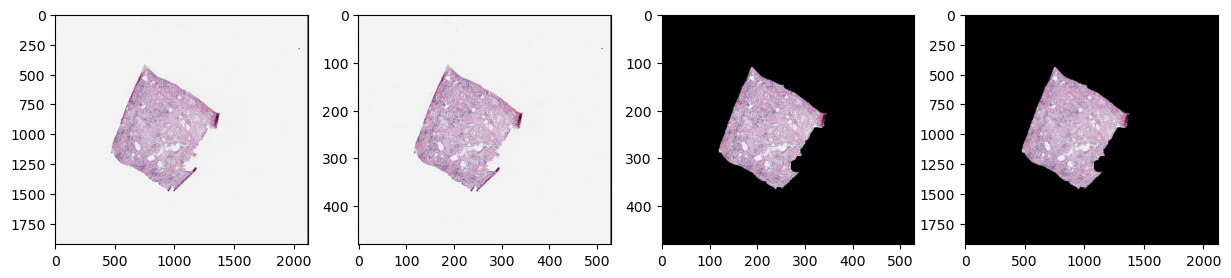

In [119]:
###################################
## GET TILE COORDINATES - CHECKS ##
###################################

## Compute pixel-tile tissue mask (For checks)
tile_map_masked = tile_map * mask
thumbnail_masked = thumbnail * cv2.resize(mask, (thumbnail.shape[1], thumbnail.shape[0]), cv2.INTER_LINEAR)[:,:,None] # (H, W)

## Visualise mask
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(thumbnail)
axes[1].imshow(tile_map)
axes[2].imshow(tile_map_masked)
axes[3].imshow(thumbnail_masked)
plt.show()
plt.close()

#
###

In [120]:
###############################
## EXTRACT PATCHES FOR MODEL ##
###############################

## Parameters
LEVEL = 0 # Downsampling level 
TILE_SIZE_MODEL = 1024 # Size of tile for model

## Remove patches too close to the edges
tile_coordinates_thinned = []
for tile_coordinates_ in tile_coordinates:
    coords_0_lo = tile_coordinates_[0] + int(TILE_SIZE/2) - int(TILE_SIZE_MODEL/2)
    coords_0_hi = tile_coordinates_[0] + int(TILE_SIZE/2) + int(TILE_SIZE_MODEL/2)
    coords_1_lo = tile_coordinates_[1] + int(TILE_SIZE/2) - int(TILE_SIZE_MODEL/2)
    coords_1_hi = tile_coordinates_[1] + int(TILE_SIZE/2) + int(TILE_SIZE_MODEL/2)
    if (coords_0_lo > 0) & (coords_0_hi < canvas_size[0]) & (coords_1_lo > 0) & (coords_1_hi < canvas_size[1]):
        tile_coordinates_thinned += [[coords_0_lo, coords_1_lo]]

## Get patches closest to grid points
tile_coordinates_thinned = select_patches_on_grid(tile_coordinates_thinned, grid_spacing=512)

## Load patches from the dataset
patches = slide_path_to_tiles_at_coordinates(WSI_PATH, tile_coordinates_thinned, TILE_SIZE_MODEL, LEVEL) # [dataset[i] for i in range(min(num_patches_to_display, len(dataset)))]
print(f'Number of patches: {len(tile_coordinates_thinned)}')

#
###

Number of patches: 645


In [123]:
########################################
## EXTRACT PATCHES FOR MODEL - CHECKS ##
########################################

## Seed
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## Display the patches
selected_patches = []
selected_patches_coordinates = []
num_patches_to_display = 64
fig, axes = plt.subplots(1, num_patches_to_display, figsize=(15, 5))
k = np.random.choice(len(patches), num_patches_to_display)
for i, ax in enumerate(axes.flat):
    if i < len(patches):        
        ax.imshow(patches[k[i]])
        ax.axis('off')
        selected_patches += [patches[k[i]]]  
        selected_patches_coordinates += [tile_coordinates_thinned[k[i]]]
    else:
        ax.axis('off') # Hide unused subplots if any
plt.tight_layout()
plt.show()

#
###

In [124]:
##################
## SAVE PATCHES ##
##################

## Save ROIs
os.makedirs(PT_OUTPUT_FOLDER, exist_ok=True)
for k in range(len(selected_patches)):
    img = cv2.cvtColor(selected_patches[k], cv2.COLOR_RGB2BGR)
    cv2.imwrite(PT_OUTPUT_FOLDER + f"/{os.path.basename(WSI_PATH)}-{selected_patches_coordinates[k][0]}-{selected_patches_coordinates[k][1]}.png", img)

#
###